In [ ]:
import scanpy as sc
import pandas as pd

# Load the AnnData object
file = "3_Extended_Pan-GI_atlas_all_lineages.h5ad"
adata = sc.read_h5ad(file)

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\_utils\__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


In [8]:
print(adata)
adata.obs.head()

AnnData object with n_obs × n_vars = 1596200 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embeddi

,sampleID,level_1_annot,level_2_annot,level_3_annot,n_counts,cell_type_ontology_term_id,sourceID,study,donorID_unified,donor_category,...,tissue_type,donor_id,cell_type,assay,disease,sex,tissue,self_reported_ethnicity,development_stage,observation_joinid
index,,,,,,,,,,,,,,,,,,,,,
AAACGAATCTCTTGCG-GSM4600896,GSM4600896,Endothelial,Vascular_endothelia,EC_venous,25675.0,CL:0002543,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,vein endothelial cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,^sYrkXY0j-
AAACGCTAGCGACCCT-GSM4600896,GSM4600896,Myeloid,Granulocyte,Mast,4769.0,CL:0000097,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,mast cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,RZn>|*!%R$
AAAGAACAGCGACCCT-GSM4600896,GSM4600896,Endothelial,Vascular_endothelia,EC_capillary,24592.0,CL:0002144,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,capillary endothelial cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,9{Lmd<I}r5
AAAGGGCAGTCACACT-GSM4600896,GSM4600896,Myeloid,Granulocyte,Mast,1532.0,CL:0000097,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,mast cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,Vr<d!plSZw
AAAGGGCCAACACAGG-GSM4600896,GSM4600896,Myeloid,DC,DC_cDC1,25171.0,CL:0000990,GSM4600898,Caetano2021,D61,control,...,tissue,Healthy 1,conventional dendritic cell,10x 3' v3,normal,male,gingiva,unknown,adult stage,<8#9OwPpEd


In [9]:
colon_tissues = [
    'colon', 'ascending colon', 'transverse colon', 'descending colon',
    'sigmoid colon', 'colonic epithelium', 'lamina propria of mucosa of colon',
    'colonic mucosa', 'rectum', 'rectosigmoid junction', 'epithelium of rectum',
    'mucosa of sigmoid colon', 'mucosa of transverse colon',
    'caecum', 'caecum epithelium', 'cecum mucosa', 'vermiform appendix'
]

adata = adata[adata.obs['tissue'].isin(colon_tissues)].copy()
print(adata)

AnnData object with n_obs × n_vars = 471003 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embeddin

In [13]:
# Filter for Large intestine
# QC: Remove cells with counts < 100 for level_2 and level_3

counts_lvl2 = adata.obs['level_2_annot'].value_counts()
print(counts_lvl2)
cells_to_keep_lvl2 = adata.obs['level_2_annot'].isin(counts_lvl2[counts_lvl2 >= 100].index)

level_2_annot
Absorptive               116957
B_plasma                  47539
Secretory                 39616
Conventional_CD4          36135
Fibroblast                34099
Transit_amplifying        26603
Mesoderm                  23707
Immature_B                23159
Mature_B                  22676
Conventional_CD8          19504
Unconventional_T/ILC      16137
Treg                       7877
Smooth_muscle              7780
Vascular_endothelia        7512
Epithelial_stem            5442
Macrophage                 5038
Neuron_progenitor          3827
Granulocyte                3195
Epithelial_progenitor      3088
Pericyte                   3031
Myofibroblast              2787
Monocyte                   2438
DC                         2357
NK                         2078
Glia                       1662
Cycling_epithelia          1604
Neuron                     1341
Enteroendocrine             994
Mesothelium                 762
Cycling_T/NK                740
Lymphatic_endothelia      

In [14]:
counts_lvl3 = adata.obs['level_3_annot'].value_counts()
print(counts_lvl3)
cells_to_keep_lvl3 = adata.obs['level_3_annot'].isin(counts_lvl3[counts_lvl3 >= 100].index)

level_3_annot
Colonocyte             73617
Goblet                 36982
B_plasma_IgA1          34773
Mature_colonocyte      31636
TA                     26603
                       ...  
Eosinophil/basophil       15
ICC                       12
Follicular_DC              9
SMC_CAPN3_cycling          4
Macrophage_CD5L            1
Name: count, Length: 101, dtype: int64


In [19]:
# Combine the QC filters
cells_to_keep = cells_to_keep_lvl2 & cells_to_keep_lvl3
adata = adata[cells_to_keep].copy()

print(adata)

AnnData object with n_obs × n_vars = 470458 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embeddin

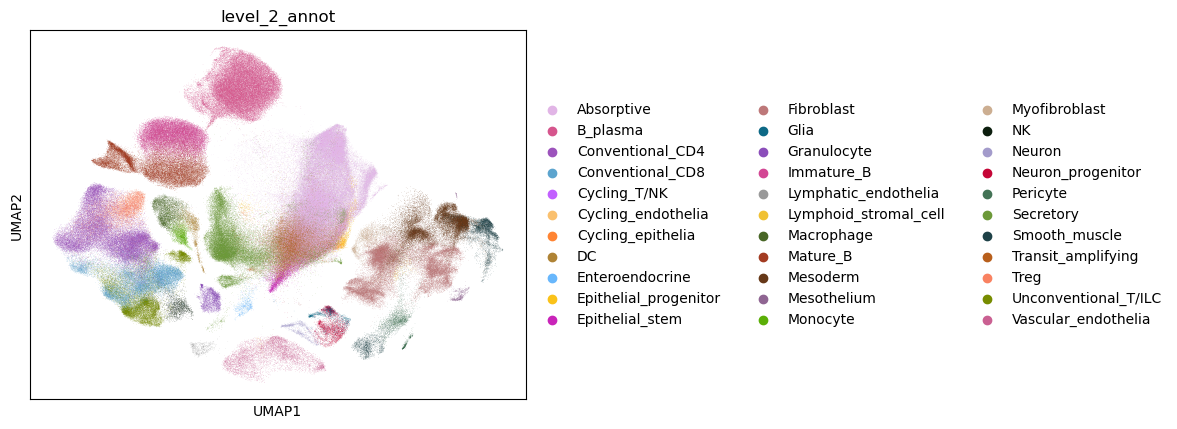

In [20]:
sc.pl.umap(adata, color="level_2_annot")

In [23]:
adata_stem = adata[adata.obs['level_2_annot'] == "Epithelial_stem"].copy()
print(adata_stem)

AnnData object with n_obs × n_vars = 5442 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embedding'

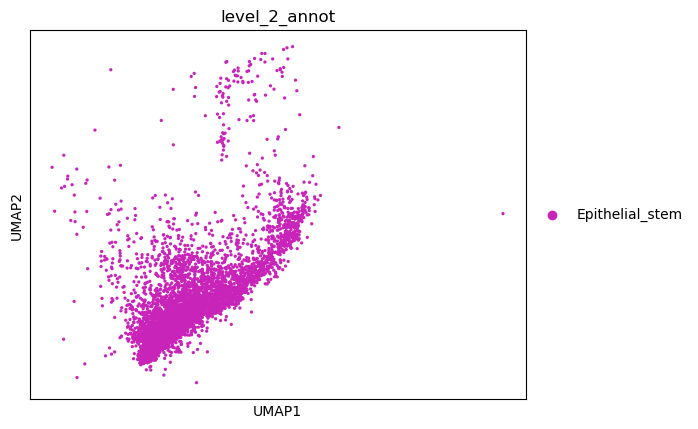

In [26]:
sc.pl.umap(adata_stem, color=["level_2_annot"])

In [31]:
# Count by tissue
print(adata_stem.obs['tissue'].value_counts())

# Count by donor
print(adata_stem.obs['donorID_unified'].value_counts())


tissue
colon                                1526
colonic epithelium                   1203
ascending colon                       520
sigmoid colon                         379
vermiform appendix                    307
lamina propria of mucosa of colon     280
epithelium of rectum                  274
descending colon                      269
caecum                                167
mucosa of transverse colon            149
transverse colon                      135
colonic mucosa                         56
mucosa of sigmoid colon                50
rectosigmoid junction                  47
rectum                                 40
caecum epithelium                      25
cecum mucosa                           15
Name: count, dtype: int64
donorID_unified
F16     310
D12     300
F18     285
D11     265
D212    250
       ... 
D173      2
D52       2
D137      2
D50       1
D51       1
Name: count, Length: 80, dtype: int64


In [40]:
study_median_per_donor = ct.apply(lambda row: row[row > 0].median(), axis=1)

keep_studies = study_total[
    (study_total >= 500) |
    (study_median_per_donor >= 50)
].index

ct_filtered = ct.loc[keep_studies]
ct_filtered = ct_filtered.loc[:, (ct_filtered != 0).any(axis=0)]

ct_filtered.loc['All'] = ct_filtered.sum()
ct_filtered['All'] = ct_filtered.sum(axis=1)

# Get filtered donors and studies
filtered_donors = [c for c in ct_filtered.columns if c != 'All']
filtered_studies = [i for i in ct_filtered.index if i != 'All']

# Build donor metadata
donor_meta = adata_stem.obs[
    adata_stem.obs['donorID_unified'].isin(filtered_donors) &
    adata_stem.obs['study'].isin(filtered_studies)
][['donorID_unified', 'study', 'donor_disease', 'control_vs_disease',
   'sex', 'age_unified', 'tissue', 'donor_category']].drop_duplicates().sort_values(['study', 'donorID_unified'])

# Write both tables to the same sheet with a gap in between
with pd.ExcelWriter("stem_cells_by_study.xlsx", engine='openpyxl') as writer:
    ct_filtered.to_excel(writer, sheet_name="Cell_counts", index=True)
    donor_meta.to_excel(writer, sheet_name="Donor_metadata", index=False)

print("Saved with 2 sheets: Cell_counts + Donor_metadata")

print("Saved to stem_cells_by_study.xlsx")
print(ct_filtered)
print(donor_meta)

Saved with 2 sheets: Cell_counts + Donor_metadata
Saved to stem_cells_by_study.xlsx
donorID_unified  D9  D11  D12  D13  D14  D15  D31  D32  D33  D35  ...  D236  \
study                                                             ...         
Elmentaite2021   81  265  300  124   50   18    0    0    0    0  ...     0   
Kong2023          0    0    0    0    0    0    0    0    0    0  ...    37   
Parikh2019        0    0    0    0    0    0   26   83  104    0  ...     0   
Wang2020          0    0    0    0    0    0    0    0    0  152  ...     0   
Yu2021            0    0    0    0    0    0    0    0    0    0  ...     0   
All              81  265  300  124   50   18   26   83  104  152  ...    37   

donorID_unified  D237  F10  F11  F12  F15  F16  F18  F25   All  
study                                                           
Elmentaite2021      0  102   54   77   32  310    0    0  1413  
Kong2023           18    0    0    0    0    0    0    0  1783  
Parikh2019          0  

In [41]:
# Pull Kong2023 (CD) and Parikh2019 (UC) stem cells only
# Exclude in utero, keep adult disease + control only
studies_keep = ['Kong2023', 'Parikh2019']

adata_dr = adata_stem[
    adata_stem.obs['study'].isin(studies_keep) &
    (adata_stem.obs['donor_category'] != 'inutero') &
    (adata_stem.obs['donor_category'].isin(['control', 'disease']))
].copy()

# Drop low-cell donors (D180: 3 cells — unreliable for co-expression)
adata_dr = adata_dr[adata_dr.obs['donorID_unified'] != 'D180'].copy()

print(adata_dr)
print()
print(adata_dr.obs.groupby(['study', 'donor_category']).size())

AnnData object with n_obs × n_vars = 2488 × 18370
    obs: 'sampleID', 'level_1_annot', 'level_2_annot', 'level_3_annot', 'n_counts', 'cell_type_ontology_term_id', 'sourceID', 'study', 'donorID_unified', 'donor_category', 'donor_disease', 'organ_unified', 'age_unified', 'sample_type', 'sample_category', 'sample_retrieval', 'tissue_fraction', 'cell_fraction_unified', 'cell_sorting', 'organ_groups', 'control_vs_disease', 'tissue_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'assay_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'suspension_type', 'tissue_type', 'donor_id', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'
    var: 'gene_symbols', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type'
    uns: 'citation', 'control_vs_disease_colors', 'default_embedding'

C:\Users\selim\AppData\Local\Temp\ipykernel_41692\3719999543.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(adata_dr.obs.groupby(['study', 'donor_category']).size())


In [44]:
adata_dr.write("stem_cells_kong_parikh_studies.h5ad")

In [ ]:
import scanpy as sc
import pandas as pd

adata_dr = sc.read_h5ad("stem_cells_kong_parikh_studies.h5ad")

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\_utils\__init__.py:27: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  from anndata import __version__ as anndata_version
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\__init__.py:36: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\readwrite.py:15: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  if Version(anndata.__version__) >= Version("0.11.0rc2"):


## Step 1 — Browse available pathway libraries and find your pathway
Use `browse_pathways()` to preview what's available **before** running the pipeline.

In [2]:
from qubo_dr.pathway import browse_pathways, preview_pathway_genes, list_enrichr_libraries

# ── List available libraries (filter by keyword) ───────────────────────────
print("=== Libraries containing 'KEGG' ===")
print(list_enrichr_libraries('KEGG'))

print("\n=== Libraries containing 'GO_Biological' ===")
print(list_enrichr_libraries('GO_Biological'))

print("\n=== Libraries containing 'Reactome' ===")
print(list_enrichr_libraries('Reactome'))

print("\n=== Libraries containing 'GO_Molecular_Function' ===")
print(list_enrichr_libraries('GO_Molecular_Function'))

=== Libraries containing 'KEGG' ===
['KEGG_2013', 'KEGG_2015', 'KEGG_2016', 'KEGG_2019_Human', 'KEGG_2019_Mouse', 'KEGG_2021_Human', 'KEGG_2026']

=== Libraries containing 'GO_Biological' ===
['GO_Biological_Process_2021', 'GO_Biological_Process_2023', 'GO_Biological_Process_2025']

=== Libraries containing 'Reactome' ===
['Reactome_2022', 'Reactome_Pathways_2024']

=== Libraries containing 'GO_Molecular_Function' ===
['GO_Molecular_Function_2021', 'GO_Molecular_Function_2023', 'GO_Molecular_Function_2025']


In [3]:
# ── Browse via Enrichr libraries (offline, no rate limit) ─────────────────
browse_pathways('Wnt', organism='human', libraries=['KEGG_2026', 'GO_Biological_Process_2025'], 
                show_genes=True, max_results=20)


[KEGG_2026  —  matches for 'Wnt']
  [ 170 genes]  WNT SIGNALING PATHWAY
             → RNF43, TLE4, RYK, TLE3, TLE2, FBXW11, TLE1, APCDD1L, CTNNBIP1, TPTEP2-CSNK1E ...

[GO_Biological_Process_2025  —  matches for 'Wnt']
  [  83 genes]  Wnt Signaling Pathway (GO:0016055)
             → NCOA3, CSNK1A1, RYK, JUP, WNT5A, CAV1, WNT5B, AXIN2, WNT9A, WNT9B ...
  [  27 genes]  Wnt Signaling Pathway, Planar Cell Polarity Pathway (GO:0060071)
             → FZD2, MAGI2, RHOA, RYK, FZD6, SMURF2, SMURF1, WNT5A, FZD7, WNT7A ...
  [  63 genes]  Canonical Wnt Signaling Pathway (GO:0060070)
             → RYK, JUP, WNT5A, CAV1, WNT5B, AXIN2, WNT9A, WNT9B, WNT16, SFRP4 ...
  [ 146 genes]  Negative Regulation of Wnt Signaling Pathway (GO:0030178)
             → RNF43, TLE5, TLE4, TLE3, TLE2, TLE1, CTNNBIP1, WNT5A, SHISA6, AMFR ...
  [ 117 genes]  Negative Regulation of Canonical Wnt Signaling Pathway (GO:0090090)
             → TLE5, TLE4, TLE3, TLE2, TLE1, WNT5A, SHISA6, AMFR, SOX13, DKK1 ...
  [  43 

{'KEGG_2026': {'WNT SIGNALING PATHWAY': ['RNF43',
   'TLE4',
   'RYK',
   'TLE3',
   'TLE2',
   'FBXW11',
   'TLE1',
   'APCDD1L',
   'CTNNBIP1',
   'TPTEP2-CSNK1E',
   'WNT5A',
   'WNT5B',
   'DKK1',
   'DKK2',
   'RBX1',
   'TLE7',
   'DKK4',
   'TLE6',
   'SFRP4',
   'SFRP5',
   'SFRP2',
   'TBL1XR1',
   'MAPK10',
   'BAMBI',
   'TP53',
   'LEF1',
   'ROCK2',
   'CTNND2',
   'LRP6',
   'LRP5',
   'FZD10',
   'APCDD1',
   'NKD1',
   'SFRP1',
   'NKD2',
   'CCAR2',
   'RUVBL1',
   'FRAT1',
   'FRAT2',
   'FRZB',
   'CCND3',
   'CCND2',
   'WIF1',
   'CCND1',
   'MYC',
   'GPC4',
   'SERPINF1',
   'CCN4',
   'TBL1X',
   'TBL1Y',
   'MAP3K7',
   'BTRC',
   'LZTS2',
   'CER1',
   'FZD2',
   'SIAH1',
   'SMAD3',
   'CREBBP',
   'FZD1',
   'PRKCG',
   'FZD4',
   'WNT10B',
   'SMAD4',
   'WNT10A',
   'FZD6',
   'WNT3A',
   'FZD5',
   'FZD8',
   'FZD7',
   'FZD9',
   'CSNK1E',
   'PRKCB',
   'PRKCA',
   'CCDC88C',
   'PROC',
   'VANGL2',
   'FOSL1',
   'VANGL1',
   'CSNK2B',
   'TCF7',
   'W

In [4]:
# ── Preview the full gene list for a specific pathway ─────────────────────
wnt_genes = preview_pathway_genes('Canonical Wnt Signaling Pathway (GO:0060070)', organism='human', library='GO_Biological_Process_2025')
print(f"\nTotal: {len(wnt_genes)} genes")

  Found 'Canonical Wnt Signaling Pathway (GO:0060070)'
  Library: [GO_Biological_Process_2025]  |  Genes: 63

[GO_Biological_Process_2025  —  'Canonical Wnt Signaling Pathway (GO:0060070)']  63 genes:
  RYK         JUP         WNT5A       CAV1        WNT5B       AXIN2     
  WNT9A       WNT9B       WNT16       SFRP4       SFRP5       BCL9      
  SFRP2       LEF1        GSK3B       LRRK2       LRP6        WNT8B     
  LRP5        FZD10       WNT8A       SFRP1       WNT6        FRAT1     
  FRAT2       FRZB        WNT11       DVL1        DVL2        DVL3      
  WNT1        WNT2        WNT3        WNT4        FZD2        SIAH1     
  FZD1        FZD4        TCF7L2      WNT10B      TCF7L1      WNT10A    
  FZD6        WNT3A       FZD5        FZD8        FZD7        SIAH2     
  WNT7A       FZD9        WNT7B       CSNK1E      SMAD7       NR4A2     
  TCF7        SNAI1       RAB5A       WNT2B       RARG        CTNNB1    
  DIXDC1      GATA3       BCL9L     

Total: 63 genes


In [5]:
# ── Preview the full gene list for a specific pathway ─────────────────────
wnt_genes = preview_pathway_genes('WNT SIGNALING PATHWAY', organism='human', library='KEGG_2026')
print(f"\nTotal: {len(wnt_genes)} genes")

  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170

[KEGG_2026  —  'WNT SIGNALING PATHWAY']  170 genes:
  RNF43       TLE4        RYK         TLE3        TLE2        FBXW11    
  TLE1        APCDD1L     CTNNBIP1    TPTEP2-CSNK1E  WNT5A       WNT5B     
  DKK1        DKK2        RBX1        TLE7        DKK4        TLE6      
  SFRP4       SFRP5       SFRP2       TBL1XR1     MAPK10      BAMBI     
  TP53        LEF1        ROCK2       CTNND2      LRP6        LRP5      
  FZD10       APCDD1      NKD1        SFRP1       NKD2        CCAR2     
  RUVBL1      FRAT1       FRAT2       FRZB        CCND3       CCND2     
  WIF1        CCND1       MYC         GPC4        SERPINF1    CCN4      
  TBL1X       TBL1Y       MAP3K7      BTRC        LZTS2       CER1      
  FZD2        SIAH1       SMAD3       CREBBP      FZD1        PRKCG     
  FZD4        WNT10B      SMAD4       WNT10A      FZD6        WNT3A     
  FZD5        FZD8        FZD7        FZD9        CSNK1E      PRKCB    

In [6]:
from pprint import pprint
pprint(wnt_genes, compact=True, width=177)

['RNF43', 'TLE4', 'RYK', 'TLE3', 'TLE2', 'FBXW11', 'TLE1', 'APCDD1L', 'CTNNBIP1', 'TPTEP2-CSNK1E', 'WNT5A', 'WNT5B', 'DKK1', 'DKK2', 'RBX1', 'TLE7', 'DKK4', 'TLE6', 'SFRP4',
 'SFRP5', 'SFRP2', 'TBL1XR1', 'MAPK10', 'BAMBI', 'TP53', 'LEF1', 'ROCK2', 'CTNND2', 'LRP6', 'LRP5', 'FZD10', 'APCDD1', 'NKD1', 'SFRP1', 'NKD2', 'CCAR2', 'RUVBL1', 'FRAT1',
 'FRAT2', 'FRZB', 'CCND3', 'CCND2', 'WIF1', 'CCND1', 'MYC', 'GPC4', 'SERPINF1', 'CCN4', 'TBL1X', 'TBL1Y', 'MAP3K7', 'BTRC', 'LZTS2', 'CER1', 'FZD2', 'SIAH1', 'SMAD3', 'CREBBP',
 'FZD1', 'PRKCG', 'FZD4', 'WNT10B', 'SMAD4', 'WNT10A', 'FZD6', 'WNT3A', 'FZD5', 'FZD8', 'FZD7', 'FZD9', 'CSNK1E', 'PRKCB', 'PRKCA', 'CCDC88C', 'PROC', 'VANGL2', 'FOSL1',
 'VANGL1', 'CSNK2B', 'TCF7', 'WNT2B', 'CTBP2', 'CTBP1', 'CUL1', 'PSEN1', 'NLK', 'RORA', 'PORCN', 'PPP3R1', 'PRKACG', 'PPP3R2', 'SOX17', 'PRKACB', 'SKP1', 'NCOA3', 'RHOA',
 'CSNK1A1', 'MMP7', 'JUN', 'AXIN2', 'NFATC4', 'AXIN1', 'NFATC3', 'NFATC2', 'WNT9A', 'NFATC1', 'WNT9B', 'SIRT1', 'MCC', 'SENP2', 'WNT16',

## Step 2 — Run DR-QUBO on Kong2023 (Crohn's disease) stem cells

In [7]:
import numpy as np
from scipy.sparse import issparse
from qubo_dr.pipeline import run_pipeline
from qubo_dr.pathway import preview_pathway_genes

# ── Subset to Kong2023 (Crohn's disease) ──────────────────────────────────
adata_cd = adata_dr[adata_dr.obs['study'] == 'Kong2023'].copy()

# Extract matrix and gene symbols
# Note: var_names in this dataset are Ensembl IDs — use var['gene_symbols'] for pathway matching
# For datasets where var_names ARE already gene symbols, use: g_cd = list(adata_cd.var_names)
X_cd     = adata_cd.X.toarray().T if issparse(adata_cd.X) else adata_cd.X.T  # → genes × cells
g_cd     = list(adata_cd.var['gene_symbols'])
batch_cd = adata_cd.obs['donor_category'].values   # 'disease' | 'control'

print(f"Kong2023 — disease: {(batch_cd == 'disease').sum()} | control: {(batch_cd == 'control').sum()}")
print(f"Matrix shape (genes × cells): {X_cd.shape}")
print(f"Gene name example: {g_cd[:5]}")

# ── Sanity check: pathway gene overlap before running ─────────────────────
wnt_genes = preview_pathway_genes('WNT SIGNALING PATHWAY', library='KEGG_2026')
overlap   = set(g.upper() for g in g_cd) & set(w.upper() for w in wnt_genes)
print(f"\nWnt genes found in data: {len(overlap)}/{len(wnt_genes)}")
print(f"Example: {sorted(overlap)[:8]}")

Kong2023 — disease: 184 | control: 1596
Matrix shape (genes × cells): (18370, 1780)
Gene name example: ['FAM87B', 'LINC00115', 'FAM41C', 'SAMD11', 'NOC2L']
  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170

[KEGG_2026  —  'WNT SIGNALING PATHWAY']  170 genes:
  RNF43       TLE4        RYK         TLE3        TLE2        FBXW11    
  TLE1        APCDD1L     CTNNBIP1    TPTEP2-CSNK1E  WNT5A       WNT5B     
  DKK1        DKK2        RBX1        TLE7        DKK4        TLE6      
  SFRP4       SFRP5       SFRP2       TBL1XR1     MAPK10      BAMBI     
  TP53        LEF1        ROCK2       CTNND2      LRP6        LRP5      
  FZD10       APCDD1      NKD1        SFRP1       NKD2        CCAR2     
  RUVBL1      FRAT1       FRAT2       FRZB        CCND3       CCND2     
  WIF1        CCND1       MYC         GPC4        SERPINF1    CCN4      
  TBL1X       TBL1Y       MAP3K7      BTRC        LZTS2       CER1      
  FZD2        SIAH1       SMAD3       CREBBP      FZD1       

Fetching pathway 'WNT SIGNALING PATHWAY' [KEGG_2026]
  Found 'WNT SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 170
  170 genes retrieved
Pathway genes in data: 166/170
Partitioning: 'disease' (test/A) vs 'control' (reference/B)
  Test (A): 184 cells | Reference (B): 1596 cells
Computing cosine similarity matrices...
Computing differential co-expression (X_diff = S_B - S_A)...
  V_diff term: disabled (no cell-state scalar provided)
Building MNN adjacency matrices (SVD d=50)...


c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Pathway prior X_net: skipped (pure pathway-gene analysis)
Assembling QUBO matrix...
  Penalty (spectral): ||Q1||_2=48.9447 → P=97.8894 (scale=2)
QUBO assembled: 166×166 | penalty P=97.8894 | K=20
Solving QUBO (SteepestDescent (classical), 1000 reads)...
  Selected 20 genes (target K=20) | energy=-39780.7647
  Saved 20 genes to qubo_genes_CD_wnt.txt
Generating plots...
Pipeline complete.

── Kong2023 CD — selected Wnt subnetwork ──
['WNT9A', 'WNT3A', 'WNT7A', 'DKK2', 'DAAM2', 'RSPO3', 'SFRP4', 'WNT2', 'DKK4', 'RSPO2', 'CER1', 'PRKACG', 'PPP3R2', 'SFRP5', 'WNT8B', 'WIF1', 'FZD10', 'FZD2', 'APCDD1L', 'TBL1Y']


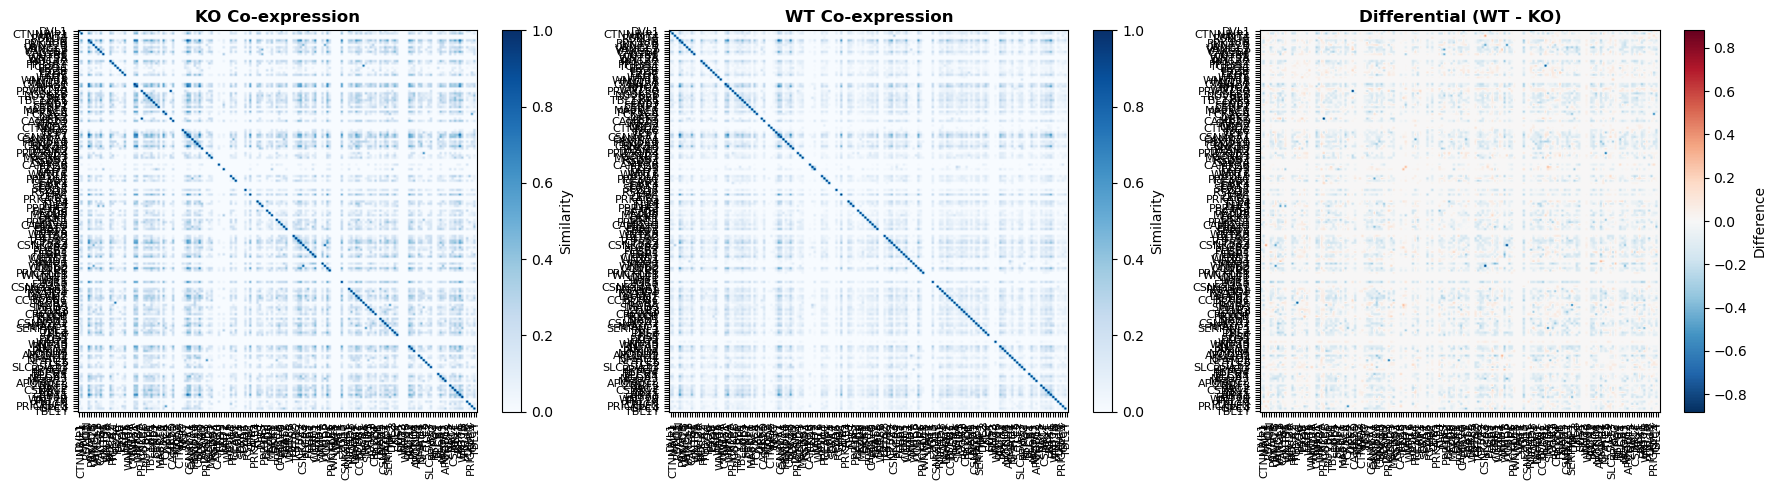

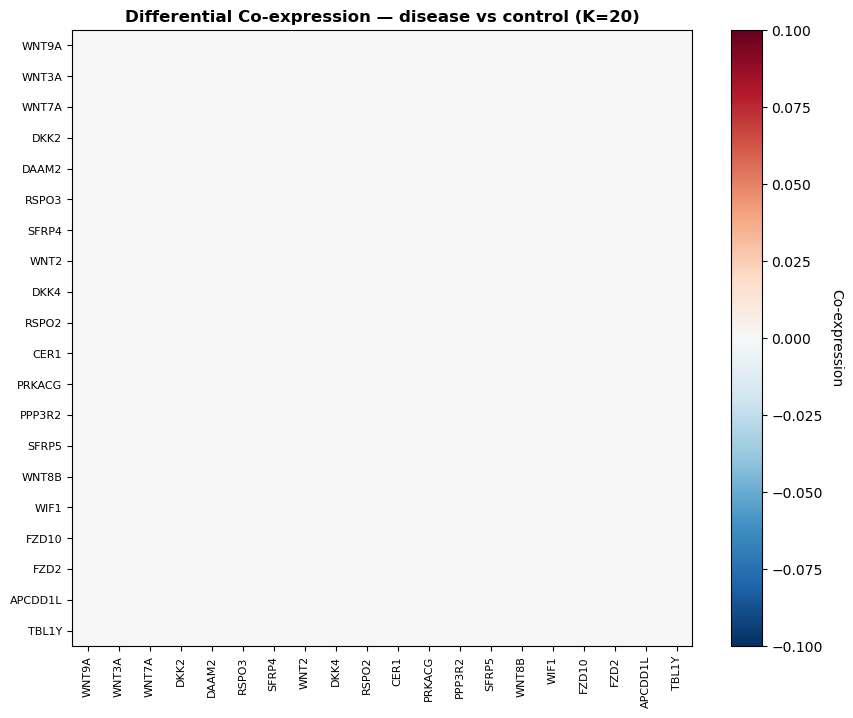

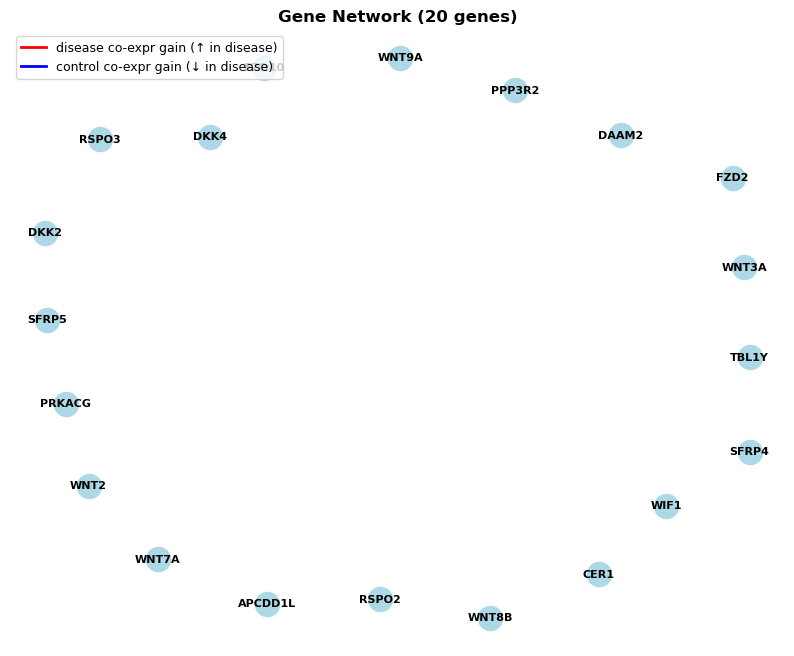

In [8]:
# ── Run DR-QUBO — Kong2023 CD — Wnt signaling ─────────────────────────────
results_cd = run_pipeline(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    test_label      = 'disease',      # condition A
    reference_label = 'control',      # condition B (reference)
    pathway_name    = 'WNT SIGNALING PATHWAY',
    library         = 'KEGG_2026',    # optional: restricts search to one library (faster)
    K               = 20,
    num_reads       = 1000,
    solver          = 'sd',
    plotit          = True,
    outfile         = 'qubo_genes_CD_wnt.txt',
)

print("\n── Kong2023 CD — selected Wnt subnetwork ──")
print(results_cd['sub_g_net'])

In [ ]:
from qubo_dr.pipeline import run_pipeline_classical

# ── Classical baseline — same data, no QUBO ───────────────────────────────
results_cd_classical = run_pipeline_classical(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    test_label      = 'disease',
    reference_label = 'control',
    pathway_name    = 'WNT SIGNALING PATHWAY',
    library         = 'KEGG_2026',
    K               = 15,
    method          = 'rowsum',     # or 'absrowsum' or 'spectral'
    plotit          = True,
    outfile         = 'classical_genes_CD_wnt.txt',
)

# ── Direct comparison ─────────────────────────────────────────────────────
qubo_genes      = set(results_cd['sub_g_net'])
classical_genes = set(results_cd_classical['sub_g_net'])

print(f"QUBO only    ({len(qubo_genes - classical_genes)}): {sorted(qubo_genes - classical_genes)}")
print(f"Classical only ({len(classical_genes - qubo_genes)}): {sorted(classical_genes - qubo_genes)}")
print(f"Shared       ({len(qubo_genes & classical_genes)}): {sorted(qubo_genes & classical_genes)}")

In [ ]:
# ── Try a different database — same call, just swap library ───────────────
# Enrichr covers KEGG, GO, Reactome, WikiPathways — no arguments needed beyond pathway_name
#
# results_cd = run_pipeline(
#     X               = X_cd,
#     g               = g_cd,
#     batch_id        = batch_cd,
#     test_label      = 'disease',
#     reference_label = 'control',
#     pathway_name    = 'Canonical Wnt Signaling Pathway (GO:0060070)',
#     library         = 'GO_Biological_Process_2025',   # ← swap library here
#     K               = 15,
#     num_reads       = 1000,
#     plotit          = True,
#     outfile         = 'qubo_genes_CD_wnt_gobp.txt',
# )
#
# Or omit library entirely — pipeline auto-searches KEGG + GO + Reactome + WikiPathways:
# results_cd = run_pipeline(..., pathway_name='wnt signaling')

## Step 3 — Run DR-QUBO on Parikh2019 (Ulcerative colitis) stem cells

In [ ]:
# ── Subset to Parikh2019 (Ulcerative colitis) ─────────────────────────────
adata_uc = adata_dr[adata_dr.obs['study'] == 'Parikh2019'].copy()

# Same extraction pattern as Kong2023 — var['gene_symbols'] because var_names are Ensembl IDs
# For datasets where var_names ARE already gene symbols, use: g_uc = list(adata_uc.var_names)
X_uc     = adata_uc.X.toarray().T if issparse(adata_uc.X) else adata_uc.X.T  # → genes × cells
g_uc     = list(adata_uc.var['gene_symbols'])
batch_uc = adata_uc.obs['donor_category'].values   # 'disease' | 'control'

print(f"Parikh2019 — disease: {(batch_uc == 'disease').sum()} | control: {(batch_uc == 'control').sum()}")
print(f"Matrix shape (genes × cells): {X_uc.shape}")

In [ ]:
# ── Run DR-QUBO — Parikh2019 UC — Wnt signaling ───────────────────────────
results_uc = run_pipeline(
    X               = X_uc,
    g               = g_uc,
    batch_id        = batch_uc,
    test_label      = 'disease',      # condition A
    reference_label = 'control',      # condition B (reference)
    pathway_name    = 'WNT SIGNALING PATHWAY',
    library         = 'KEGG_2026',
    K               = 15,
    num_reads       = 1000,
    plotit          = True,
    outfile         = 'qubo_genes_UC_wnt.txt',
)

print("\n── Parikh2019 UC — selected Wnt subnetwork ──")
print(results_uc['sub_g_net'])

## Step 4 — Compare CD vs UC subnetworks

In [ ]:
cd_genes = set(results_cd['sub_g_net'])
uc_genes = set(results_uc['sub_g_net'])

shared   = cd_genes & uc_genes
cd_only  = cd_genes - uc_genes
uc_only  = uc_genes - cd_genes

print(f"Shared genes ({len(shared)}): {sorted(shared)}")
print(f"CD-only  ({len(cd_only)}): {sorted(cd_only)}")
print(f"UC-only  ({len(uc_only)}): {sorted(uc_only)}")


In [ ]:
# ── Per-gene contribution scores ──────────────────────────────────────────
import pandas as pd

def scores_df(results, study_label):
    return pd.DataFrame({
        'gene' : results['sub_g_net'],
        'score': results['sub_Qv'],
        'study': study_label,
    }).sort_values('score', ascending=False)

df_cd = scores_df(results_cd, 'Kong2023_CD')
df_uc = scores_df(results_uc, 'Parikh2019_UC')

print("── Top CD genes by contribution ──")
print(df_cd.head(10).to_string(index=False))
print("\n── Top UC genes by contribution ──")
print(df_uc.head(10).to_string(index=False))
